In [2]:
from qiskit import __version__
 
print(__version__)

2.1.1


`AerSimulator` is a noisy quantum circuit simulator backend that supports multiple simulation methods and can mimic an IBMQ backend.

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

#### writing non reversible functions as reversible ones

<img src="./images/unitary-query-gate.svg" width=500>

The input is represented by a function $f:Σ→Σ$ ; $ Σ=\{0,1\}$ <br>
$f_1$ = constant-0 <br>
$f_2$ = identity <br>
$f_3$ = negation <br>
$f_4$ = constant-1 <br>
$f_1$ and $f_4$ are constant functions <br>
$f_2$ and $f_3$ are balanced functions 

output : 0 for constant 1 for balanced

balanced means the number of input strings on which the function takes the value 0 is equal to the number of input strings on which the function takes the value 1

### Deutsch circuit

<img src="./images/Deutsch-circuit.svg" width=500>

$H∣0⟩= \frac{1}{\sqrt2}∣0⟩+ \frac{1}{\sqrt2}∣1⟩ = ∣+⟩$ <br>
​$H∣1⟩= \frac{1}{\sqrt2}∣0⟩ − \frac{1}{\sqrt2}∣1⟩ = ∣−⟩$


$∣0⊕a⟩−∣1⊕a⟩=(−1)^a(∣0⟩−∣1⟩)$ <br>
Although the action of the $U_f$ gate on standard basis states leaves the top/rightmost qubit alone and XORs the function value onto the bottom/leftmost qubit, here what happens is that the state of the top/rightmost qubit get changed (in general) while the state of the bottom/leftmost qubit remains the same before and after the $U_f$ gate is performed. This phenomenon is known as the phase kickback.

In [ ]:
def deutsch_query(case: int):
    # This function generates a quantum circuit for one of the 4 functions from one bit to one bit 
    # input on top/right qubit and output on bottom/left qubit.
 
    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")

    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)  # CNOT gate
    if case in [3, 4]:
        f.x(1)  # Pauli-X gate
    return f

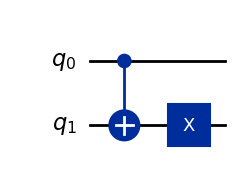

In [ ]:
display(deutsch_query(3).draw(output="mpl"))

"The `barrier` function creates a visual separation making the circuit diagram more readable, and it also prevents Qiskit from performing various simplifications and optimizations across barriers during compilation when circuits are run on real hardware."

By default, `compose` creates a new circuit object, leaving self untouched. For most uses of this function, it is far more efficient to set inplace=True and modify the base circuit in-place.

In [ ]:
def deutsch_circuit(function: QuantumCircuit):
    # Compiles a circuit for use in Deutsch's algorithm.
 
    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)   # n input qubits + 1 output qubit, n classical bits for measurement
 
    qc.x(n)     # Not gate on the output qubit
    qc.h(range(n + 1)) # Hadamard on all qubits
 
    qc.barrier()
    qc.compose(function, inplace=True)      # oracle
    qc.barrier()

    qc.h(range(n))      # Hadamard on input qubits
    qc.measure(range(n), range(n))      # measure the input qubits

    return qc

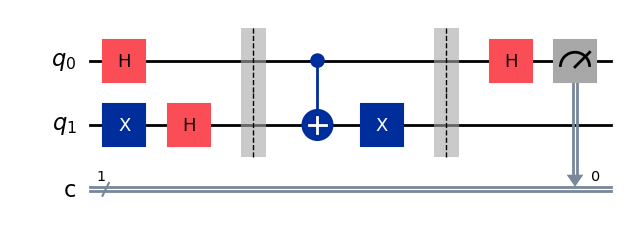

In [ ]:
display(deutsch_circuit(deutsch_query(3)).draw(output="mpl"))

**Intuition** : Negation gate neutralizes the difference within the categories. CNOT get magnifies the difference between the categories

In [36]:
def deutsch_algorithm(function: QuantumCircuit):
    # Determine if a one-bit function is constant or balanced.
 
    qc = deutsch_circuit(function)
 
    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if measurements[0] == "0":
        return "constant"
    return "balanced"

In [ ]:
f = deutsch_query(4)
display(deutsch_algorithm(f))

'constant'

`execute` is a helper function that performs three tasks for the user:

1. Circuits are rewritten to match the constraints of a given backend and optimized.

2. The rewritten circuits are packaged for submission.

3. The packaged circuits are submitted to the device.

#### Init stage
This pass is primarily useful if you want to include your own initial optimizations. Because most layout and routing algorithms are only designed to work with single- and two-qubit gates, this stage is also used to translate any gates that operate on more than two qubits, into gates that only operate on one or two qubits.

#### Layout stage
This pass applies a layout, mapping the virtual qubits in your circuit to the QPU's physical qubits.
3. `Routing stage` <br>
This pass inserts the appropriate amount of SWAP gates in order to execute the circuits using the selected layout to make it compatible with the QPU's connectivity.

By default, `SabreLayout` runs both layout and routing, and returns the transformed circuit.

The output from transpile varies due to the stochastic swap mapper. Qiskit uses a stochastic heuristic algorithm called `SabreSwap` to compute a good, but not necessarily optimal, SWAP mapping.

`transpile` a circuit several times, e.g. 10, and take the one with the lowest depth.



#### Translation stage
This pass translates the gates in the circuit to the QPU's basis set of instructions. <br>

1. If a `SWAP gate` is not a native gate to the target backend, this requires three CNOT gates.

2. A `Toffoli`, or controlled-controlled-not gate (ccx), is a three-qubit gate. Given that our basis gate set includes only single- and two-qubit gates, this operation must be decomposed. However, it is quite costly. <br>
For every Toffoli gate in a quantum circuit, the hardware may execute up to six CNOT gates and a handful of single-qubit gates.

#### Optimization stage
* For optimization_level=1, this stage prepares `Optimize1qGatesDecomposition` and `CXCancellation`, which combine chains of single-qubit gates and cancel any back-to-back CNOT gates.
* For optimization_level=2, this stage uses the `CommutativeCancellation`, which removes redundant gates by exploiting commutation relations.
* For optimization_level=3, this stage prepares the following passes:
    * `Collect2qBlocks`
    * `ConsolidateBlocks`
    * `UnitarySynthesis`
    * `Optimize1qGateDecomposition`
    * `CommutativeCancellation`

    Additionally, this stage also executes a few final checks to make sure that all instructions in the circuit are composed of the basis gates available on the target backend.    

#### Scheduling stage

    The scheduling stage is typically used once the circuit has been translated to the target basis, mapped to the device, and optimized. These passes focus on accounting for all the idle time in a circuit. At a high level, the scheduling pass can be thought of as explicitly inserting delay instructions to account for the idle time between gate executions and to inspect how long the circuit will be running on the backend.